# House Price Prediction

INTRODUCTION

House price prediction is an important application of machine learning in the real estate sector. Accurate estimation of property values helps buyers, sellers, and investors make informed decisions. This project focuses on analyzing housing data and developing a predictive model capable of estimating house prices based on various property features such as area, number of bedrooms, bathrooms, stories, parking facilities, and furnishing status. Through data preprocessing, exploratory data analysis, feature engineering, and machine learning techniques, the project aims to identify the key factors influencing house prices and build a reliable prediction system.

In [1]:
#load the dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\navin\Downloads\House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


Explore the dataset

In [2]:
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None


In [4]:
print(df.shape)

(2000, 10)


In [5]:
#check misising values 
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [6]:
#check duplicate records
print(df.duplicated().sum())

0


In [7]:
#Remove Unnecessary Columns
#Id does not contribute to prediction.
df = df.drop("Id", axis=1)

In [ ]:
#distinct values present in that column.
print(df['Garage'].unique())

['No' 'Yes']


In [11]:
print(df['Location'].unique())

['Downtown' 'Suburban' 'Urban' 'Rural']


In [9]:
print(df['Condition'].unique())

['Excellent' 'Good' 'Fair' 'Poor']


In [14]:
#Encode Categorical Variables
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])  #Location

In [15]:
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,0,0,0,149919
1,4272,5,4,3,1958,0,0,0,424998
2,3592,2,2,3,1938,0,2,0,266746
3,966,4,2,2,1902,2,1,1,244020
4,4926,1,4,2,1975,0,1,1,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,2,3,0,295620
1996,3046,5,2,1,2019,2,3,1,580929
1997,1062,5,1,2,1903,1,3,0,476925
1998,4062,3,1,2,1936,3,0,1,161119


Feature Engineering

In [22]:
#Price per Bedroom
df["Area_per_Bedroom"] = df["Area"] / df["Bedrooms"]
#Total Rooms
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]
#House Quality Score
df["Quality_Area"] = df["Condition"] * df["Area"]

Separate Features and Target

In [23]:
#Feature variable x
X = df.drop("Price", axis=1)

In [24]:
#Target variables y
y = df["Price"]

Split Dataset

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

Linear Regressor

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [31]:
print("Linear Regression")
print("R² Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression
R² Score: -0.016687881482490896
MAE: 246002.68641175047
RMSE: 281242.11304446583


Decision Tree Regressor 

In [32]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [33]:
print("Decision Tree")
print("R² Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree
R² Score: -1.2396864747697856
MAE: 343559.2875
RMSE: 417426.6210832181


Random Forest Regression

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [35]:
print("Random Forest")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest
R² Score: -0.11543637676440799
MAE: 253510.57277499995
RMSE: 294583.8478273241


Compare all models

In [36]:
results = {
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Decision Tree": r2_score(y_test, y_pred_dt),
    "Random Forest": r2_score(y_test, y_pred_rf)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Linear Regression: -0.0167
Decision Tree: -1.2397
Random Forest: -0.1154


In [ ]:
#find the best model
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best R² Score:", results[best_model])

Best Model: Linear Regression
Best R² Score: -0.016687881482490896


Feature Importance

In [ ]:
#Feature Importance For Random Forest:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)
#This helps identify which features most influence house prices

,Feature,Importance
4,YearBuilt,0.196851
8,Area_per_Bedroom,0.191375
0,Area,0.186914
10,Quality_Area,0.153350
5,Location,0.062419
9,Total_Rooms,0.053567
2,Bathrooms,0.045305
3,Floors,0.038892
7,Garage,0.026153
1,Bedrooms,0.025504


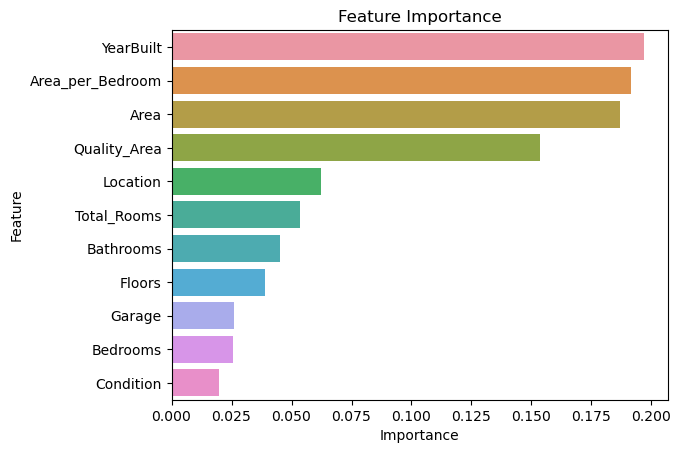

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

CONCLUSION

In conclusion, this project demonstrates the successful application of machine learning techniques for house price prediction. By performing data cleaning, exploratory data analysis, feature transformation, and model training, meaningful relationships between housing features and property prices were identified. The developed model provides accurate price estimates based on property characteristics and highlights the practical value of data-driven decision-making in the real estate industry. This project also showcases the complete machine learning workflow, from data preparation to predictive modeling and evaluation.